# ラマンスペクトル変換(波長較正，感度較正の後に行う．)

In [2]:
from echelle_pkg.convert_raman import *

In [3]:
files_cmos = {
    "orders": "pattern.txt",
    "sphr": "20250123_sphere_100ms.tif",
    "bkgr": "20250123_sphereback_100ms.tif",
}

calibration_path = "calibration_file_examples"

cb = setup_calibration(calibration_path, files_cmos)

## スペクトル計算

In [ ]:
path = "../data/BoronFilm_Raman_data"       # 自分のラマン分光データ

data_dir = f"{path}/20251202_deposited-boronfilm_10s"       # スペクトル
bg_dir = f"{path}/20251202_deposited-boronfilm-back_10s"        # バックグラウンド

fb = "20251202_deposited-boronfilm_10s_"            # スペクトル
fb_bg = "20251202_deposited-boronfilm-back_10s_"    # バックグラウンド

ext = ".tif"                # 画像形式
frange = range(0, 17)       # 積算枚数

raman_list = compute_order_spectra(data_dir, fb, ext, frange, cb)
raman_bg_list = compute_order_spectra(bg_dir, fb_bg, ext, frange, cb)

raman_sum = sum_spectra(raman_list)
raman_bg_sum = sum_spectra(raman_bg_list)

raman_subtracted = raman_sum - raman_bg_sum     # バックグラウンド減算

## 感度較正データの読み込み
### Sensitivity_calibration.ipynbを先に実行してcsvファイルを取得しておく

In [7]:
order_sdata = load_sensitivity_data(f"{calibration_path}/sensitivity_data.csv")

calibrated = apply_sensitivity_correction(
    raman_subtracted,
    order_sdata,
)

## プロット

In [8]:
wavelength = stitch_wavelength(order_sdata)
intensity = stitch_intensity(calibrated)

raman_shift = convert_to_raman_shift(wavelength)

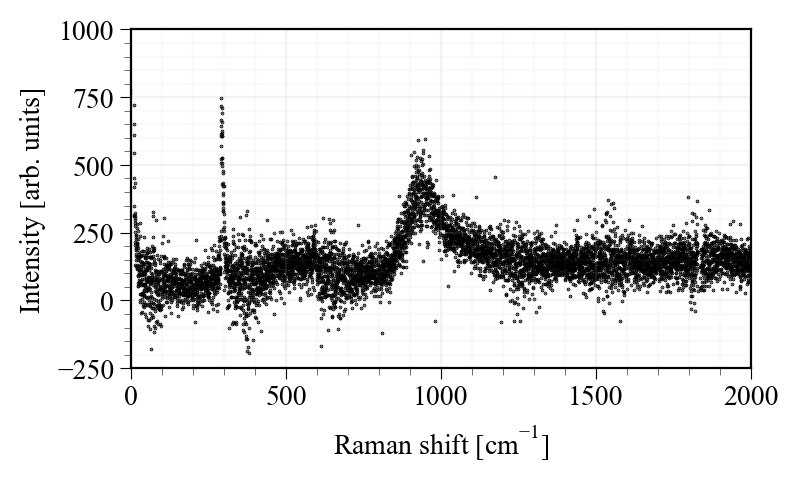

In [11]:
fig = plt.figure(figsize=(4, 2.2), dpi=200)
ax = fig.add_subplot(1,1,1)
ax.scatter(raman_shift, intensity,c='k',s=0.1)

rcParams['font.family'] = 'Times New Roman'
rcParams['mathtext.fontset'] = 'custom'
rcParams['mathtext.rm'] = 'Times New Roman'
rcParams["font.size"] = 10
rcParams["xtick.major.pad"] = 2
rcParams["ytick.major.pad"] = 2

ax.set_xlabel("Raman shift [$\mathrm{cm^{-1}}$]")
ax.set_ylabel("Intensity [arb. units]")
ax.set_xlim(0, 2000)
ax.set_ylim(-250,1000)
ticks_visual(ax, l1=4, l2=2.5, w1=0.4, w2=0.2)
grid_visual(ax, alpha=[0.05, 0.15])
plt.savefig('figures/DepositedBoronFilm.png',dpi=200,bbox_inches='tight')